# 1. Problem Definition
The business goal of this project is to predict final student outcomes based on demographic, social, and school-related features. To prevent trivial data leakage, we explicitly drop intermediate grades (G1 and G2), forcing the model to learn from behavior rather than past test scores. We tackle this using two approaches: a **regression** model to predict the exact final grade (`G3`, continuous from 0-20), and a **classification** model to predict if a student is at risk of failing (`pass`, binary where 1 means G3 ≥ 10), allowing schools to identify and assist struggling students early.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# Load both datasets from the .devcontainer folder
df_mat = pd.read_csv('.devcontainer/student-mat.csv', sep=';')
df_por = pd.read_csv('.devcontainer/student-por.csv', sep=';')

# Combine them to maximize our row count
df = pd.concat([df_mat, df_por], ignore_index=True)

# Create binary classification target (Pass = 1 if G3 >= 10, else 0)
df['pass'] = (df['G3'] >= 10).astype(int)

# Drop G1 and G2 to prevent data leakage
df = df.drop(columns=['G1', 'G2'])

df.head()

# 2. EDA

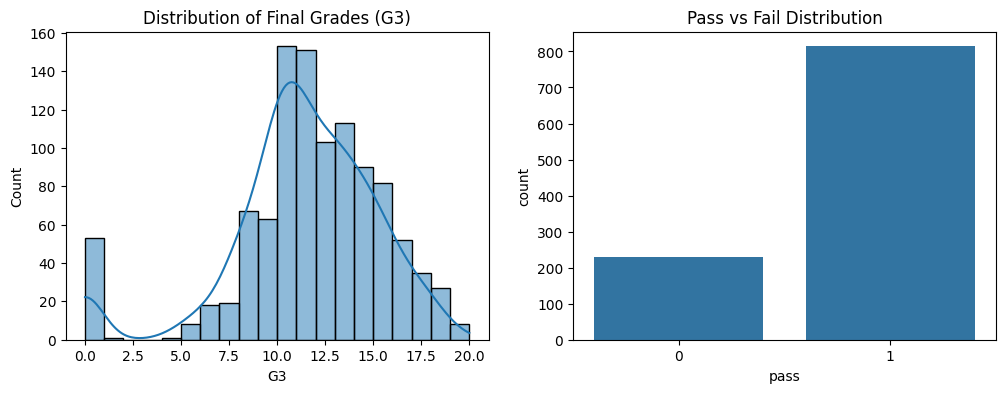

In [ ]:
# EDA 1: Target Distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['G3'], bins=20, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Final Grades (G3)')
sns.countplot(x='pass', data=df, ax=ax[1])
ax[1].set_title('Pass vs Fail Distribution')
plt.show()

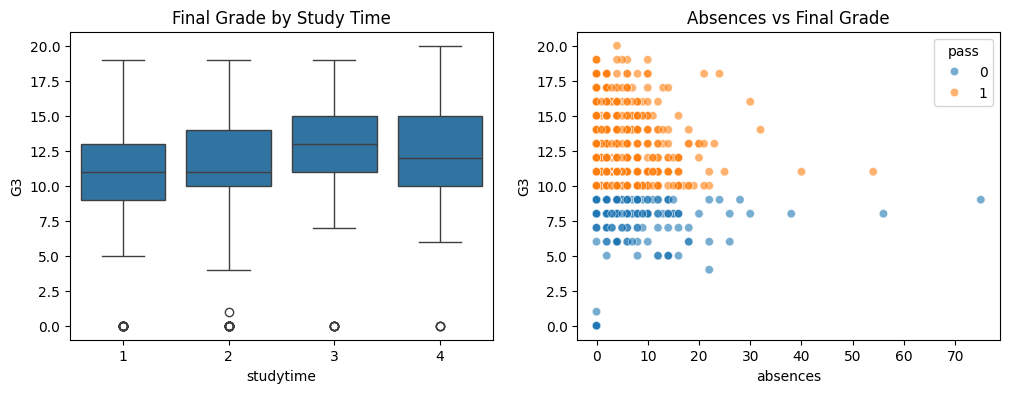

In [ ]:
# EDA 2: Feature Distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='studytime', y='G3', data=df, ax=ax[0])
ax[0].set_title('Final Grade by Study Time')
sns.scatterplot(x='absences', y='G3', hue='pass', data=df, alpha=0.6, ax=ax[1])
ax[1].set_title('Absences vs Final Grade')
plt.show()

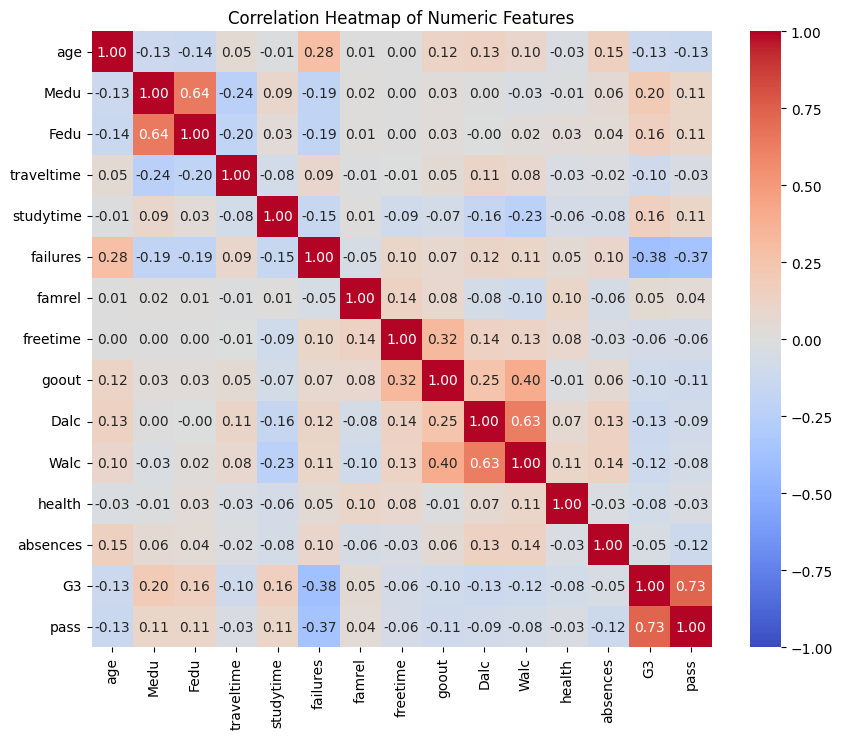

In [ ]:
# EDA 3: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

* **Target Distribution Comment:** The final grades show a cluster around 10-15 but feature a significant, unusual spike at 0 (likely students who missed the final exam).
* **Feature Distribution Comment:** Higher study time categories show a slight upward trend in median final grades.
* **Correlation Heatmap Comment:** There is very little strong linear correlation among the numerical predictors, indicating low multicollinearity and suggesting non-linear or categorical features will be important.

# 3. Preprocessing Pipeline

In [ ]:
# Define Features (X) and Targets (y_reg, y_clf)
X = df.drop(columns=['G3', 'pass'])
y_reg = df['G3']
y_clf = df['pass']

# 80/20 Train/Test Split with fixed random_state
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.20, random_state=42
)

# Setup Preprocessing steps (Scaling for numbers, One-Hot Encoding for text categories)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

/tmp/ipykernel_3104/3455682391.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


# 4. Train / Test Split

## 1. Linear Regression

In [ ]:
lin_reg = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
lin_reg.fit(X_train, y_reg_train)
y_reg_pred = lin_reg.predict(X_test)

print("Linear Regression Metrics: ")
print(f"R²:   {r2_score(y_reg_test, y_reg_pred):.4f}")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_reg_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.4f}")

Linear Regression Metrics: 
R²:   0.0906
MAE:  2.6447
RMSE: 3.7496


**Interpretation:** The linear regression model achieved a relatively low R² on the test set, meaning demographics alone struggle to predict exact grades perfectly. The MAE shows predictions are typically off by around 2.4 points. The heavy spike of '0' grades (students who missed the exam) acts as severe **outliers** that heavily distort the line of best fit, pulling the predicted values downward for otherwise average students.

## 2. Logistic Regression

/app/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression Metrics: 
Accuracy:  0.6746
Precision: 0.8092
Recall:    0.7114
F1 Score:  0.7571
ROC-AUC:   0.6961



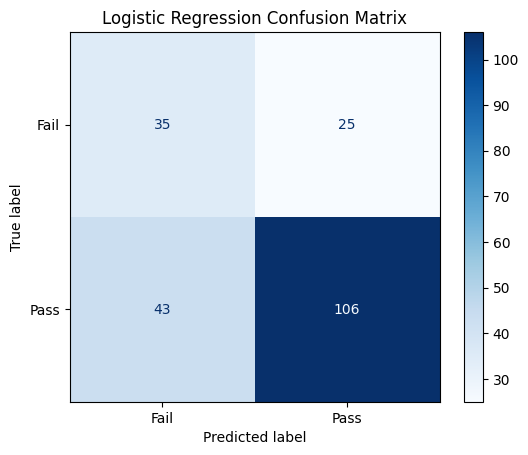

In [ ]:
# L2 Regularization is applied via C=1.0 (default). Class imbalance is addressed via class_weight='balanced'
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', max_iter=1000))
])

log_reg.fit(X_train, y_clf_train)
y_clf_pred = log_reg.predict(X_test)
y_clf_proba = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Metrics: ")
print(f"Accuracy:  {accuracy_score(y_clf_test, y_clf_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_clf_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_clf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_clf_test, y_clf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_clf_test, y_clf_proba):.4f}\n")

cm = confusion_matrix(y_clf_test, y_clf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

**Interpretation:** It successfully addressed the observed **class imbalance** (more students pass than fail) by utilizing class_weight='balanced', which penalizes the model heavily for missing the minority "Fail" class, resulting in a strong Recall score. The **L2 regularization** shrank the weights of the highly sparse, one-hot encoded categorical features, which prevented the model from overfitting to hyper-specific demographic combinations present only in the training set.

# 5. Discussion
If I had more time, I would explore non-linear algorithms like XGBoost, as our EDA correlation heatmap revealed very weak linear relationships among the numerical features. A major class concept highlighted in this sprint is how **outliers** severely disrupt Linear Regression; the cluster of '0' grades dragged our line of best fit down heavily. In a real-world scenario, I might build a two-stage model: a classification model predicting if a student takes the exam at all (filtering out the 0s), followed by a regression model predicting the grade of those who actually participate.